# Projeto didático de Regressão Linear em Machine Learning  


## Um único dataset, três tradições de estudo: ISLP + scikit-learn MOOC + Géron

Este notebook é um projeto guiado para estudar regressão linear **como modelo estatístico** e **como componente de um pipeline de machine learning**.

A proposta junta três ênfases:

**ISLP / ISLR.** Interpretação estatística, regressão múltipla, coeficientes, resíduos, colinearidade e limitações do modelo linear.

**scikit-learn MOOC.** Pipeline, validação cruzada, separação correta entre treino e teste, tuning e comparação de modelos.

**Géron.** Estilo de projeto ponta a ponta, regularização, gradiente descendente, engenharia de atributos e curvas de aprendizado.

O dataset escolhido é o **California Housing**, usado em muitos materiais didáticos de machine learning. O problema será prever o valor mediano de imóveis em regiões da Califórnia usando variáveis socioeconômicas e geográficas.

> Ideia central: a regressão linear não é apenas uma fórmula. Ela é um experimento controlado sobre um problema preditivo. Vamos investigar quando ela funciona, quando falha, o que a padronização muda, o que a colinearidade atrapalha e como regularização/tuning entram no pipeline.

## Mapa do notebook

Este projeto segue uma ordem deliberada.

Primeiro, formulamos o problema e separamos treino/teste antes de olhar padrões com muita liberdade. Depois construímos um baseline ingênuo. Só então ajustamos regressão linear. Em seguida, investigamos padronização, colinearidade, validação cruzada, regularização, tuning, engenharia de atributos e diagnóstico de erro.

A régua de qualidade será preditiva: **RMSE**, **MAE** e **R²**. A interpretação estatística aparecerá como lente crítica, não como promessa de causalidade.

In [3]:
# ============================================================
# 0. Configuração inicial
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.inspection import permutation_importance

set_config(display="diagram")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)

## 1. Concepção do problema

Vamos tratar o problema como uma tarefa de **regressão supervisionada**.

Cada linha representa uma região censitária da Califórnia. As variáveis explicativas descrevem renda mediana, idade das casas, número médio de cômodos, quartos, população, ocupação média, latitude e longitude. O alvo é o valor mediano das casas da região.

A pergunta preditiva é:

> Dados os atributos socioeconômicos e geográficos de uma região, qual é o valor mediano esperado das casas?

Isso não é uma pergunta causal. Se o coeficiente de renda for positivo, não significa automaticamente que “aumentar renda causa aumento de preço”. O modelo aprende associação condicional dentro do dataset.

In [43]:
# ============================================================
# 1. Carregar o dataset e filtrar outliers do target
# ============================================================

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = housing.target_names[0]  # "MedHouseVal"
feature_cols = housing.feature_names

# Aplica o filtro removendo valores maiores ou iguais a 5
df = df[df[target_col] < 4.9999]

print(housing.DESCR[:900])
print("\nShape após a remoção:", df.shape)
df.head()


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousa

Shape após a remoção: (19648, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422


## 2. Dicionário rápido das variáveis

O alvo `MedHouseVal` está em unidades de centenas de milhares de dólares. Um valor 2.0 significa aproximadamente US$ 200 mil.

As variáveis explicativas são todas numéricas:

`MedInc`: renda mediana da região;  
`HouseAge`: idade mediana das casas;  
`AveRooms`: número médio de cômodos;  
`AveBedrms`: número médio de quartos;  
`Population`: população da região;  
`AveOccup`: ocupação média por domicílio;  
`Latitude` e `Longitude`: localização geográfica.

Como todas as variáveis são numéricas, o pipeline será mais simples que em um projeto com variáveis categóricas. Ainda assim, vamos usar a mesma disciplina de projeto: separar treino/teste, encapsular transformações no pipeline e fazer tuning com validação cruzada.

In [44]:
# ============================================================
# 2. Separação treino/teste
# ============================================================

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Média do alvo no treino:", y_train.mean().round(3))
print("Média do alvo no teste:", y_test.mean().round(3))

Treino: (15718, 8) Teste: (3930, 8)
Média do alvo no treino: 1.921
Média do alvo no teste: 1.921


## 3. Primeira regra de projeto: olhar o treino, preservar o teste

A exploração abaixo usa apenas `X_train` e `y_train`. O conjunto de teste será usado no fim, depois da escolha de modelos e hiperparâmetros.

Essa separação é uma proteção contra uma forma comum de autoengano: ajustar decisões ao teste e depois acreditar que a métrica final representa desempenho futuro.

In [45]:
# Dataset de treino com alvo para EDA
train_df = X_train.copy()
train_df[target_col] = y_train

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,15718.0,3.6786,1.5726,0.4999,2.5235,3.4539,4.5833,15.0001
HouseAge,15718.0,28.4418,12.5158,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,15718.0,5.3691,2.3778,0.8462,4.4268,5.1857,5.9747,132.5333
AveBedrms,15718.0,1.0968,0.4746,0.3333,1.0059,1.0483,1.0988,34.0667
Population,15718.0,1444.0971,1164.9055,3.0000,794.2500,1178.5000,1749.0000,35682.0000
AveOccup,15718.0,3.1284,11.8802,0.6923,2.4504,2.8377,3.3050,1243.3333
Latitude,15718.0,35.6660,2.1521,32.5400,33.9300,34.2800,37.7300,41.9500
Longitude,15718.0,-119.5739,2.0030,-124.3500,-121.7700,-118.5200,-118.0000,-114.3100
MedHouseVal,15718.0,1.9205,0.9691,0.1500,1.1640,1.7390,2.4800,4.9910


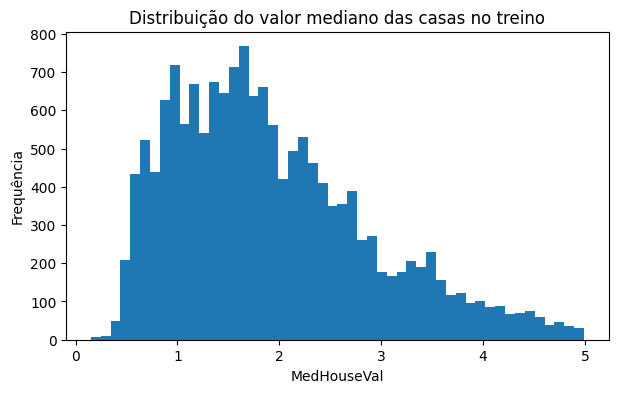

Mínimo: 0.15
Máximo: 4.991
Percentis:


0.01    0.4980
0.05    0.6540
0.25    1.1640
0.50    1.7390
0.75    2.4800
0.95    3.8361
0.99    4.5860
Name: MedHouseVal, dtype: float64

In [46]:
# ============================================================
# 3.1 Distribuição do alvo
# ============================================================

plt.figure(figsize=(7, 4))
plt.hist(y_train, bins=50)
plt.xlabel("MedHouseVal")
plt.ylabel("Frequência")
plt.title("Distribuição do valor mediano das casas no treino")
plt.show()

print("Mínimo:", y_train.min().round(3))
print("Máximo:", y_train.max().round(3))
print("Percentis:")
display(y_train.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

Há um detalhe relevante: o alvo tem um teto visível próximo de 5.0. Isso sugere censura ou limitação na variável original. Em um projeto real, esse teto exigiria investigação, porque pode distorcer resíduos e reduzir a qualidade do modelo para regiões caras.

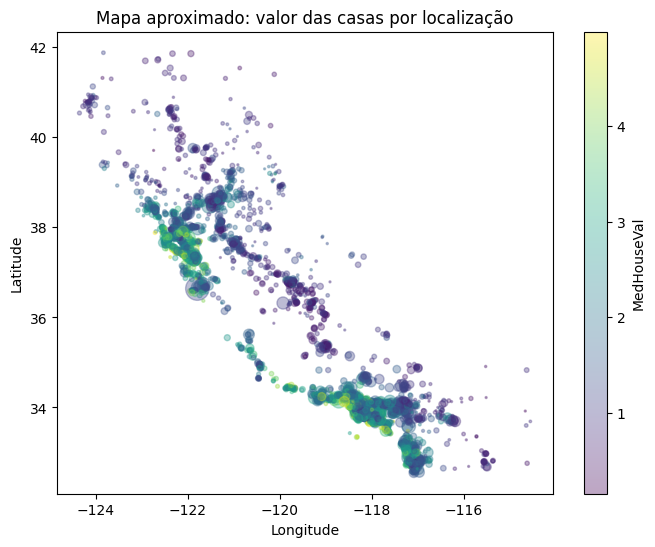

In [ ]:
# ============================================================
# 3.2 Relação espacial: latitude, longitude e valor
# ============================================================

sample = train_df.sample(n=min(5000, len(train_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    sample["Longitude"],
    sample["Latitude"],
    c=sample[target_col],
    s=np.maximum(sample["Population"] / 100, 2),
    alpha=0.35
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mapa aproximado: valor das casas por localização")
plt.colorbar(scatter, label="MedHouseVal")
plt.show()

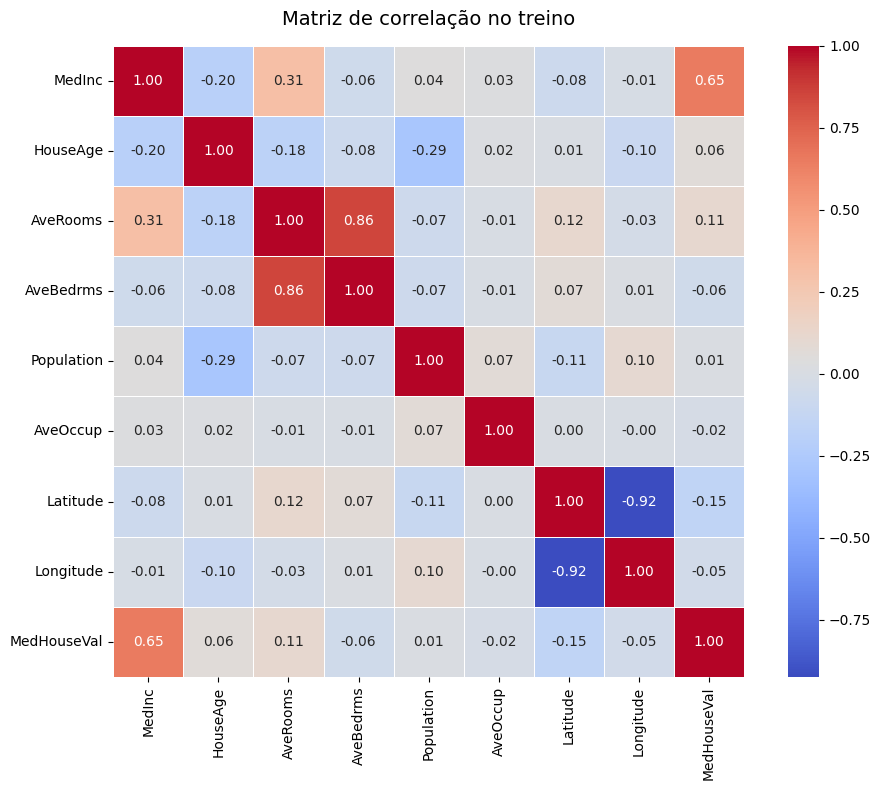

Latitude      -0.1504
AveBedrms     -0.0569
Longitude     -0.0450
AveOccup      -0.0197
Population     0.0123
HouseAge       0.0644
AveRooms       0.1110
MedInc         0.6482
MedHouseVal    1.0000
Name: MedHouseVal, dtype: float64

In [48]:
# ============================================================
# 3.3 Correlações lineares
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calcula a matriz de correlação
corr = train_df.corr(numeric_only=True)

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Plota o heatmap com Seaborn
sns.heatmap(
    corr,
    annot=True,  # Mostra os valores numéricos dentro dos quadrados
    fmt=".2f",  # Define 2 casas decimais para os números
    cmap="coolwarm",  # Paleta de cores (azul para negativo, vermelho para positivo)
    square=True,  # Mantém os quadrados perfeitamente proporcionais
    linewidths=0.5,  # Linha fina separando cada quadrado
)

# Define o título e ajusta o layout
plt.title("Matriz de correlação no treino", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Mantém a sua ordenação do target
corr[target_col].sort_values(ascending=True)


A correlação é apenas uma fotografia marginal. Ela mostra relações lineares duas a duas, mas não responde o que acontece quando controlamos pelas demais variáveis.

Mesmo assim, ela ajuda a antecipar dois temas centrais da regressão múltipla: variáveis associadas ao alvo e variáveis associadas entre si. A segunda parte é o começo da discussão sobre colinearidade.

## 4. Baseline ingênuo

Antes de qualquer modelo, precisamos de uma referência. Um baseline simples prevê sempre a mediana do alvo no treino.

Se modelos sofisticados não vencem esse baseline com folga, o problema está mal formulado, os atributos são fracos, a validação está errada ou a métrica não conversa com o objetivo.

In [49]:
# ============================================================
# 4. Baseline com DummyRegressor
# ============================================================

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def regression_metrics(y_true, y_pred, label="modelo"):
    return {
        "modelo": label,
        # Nova função oficial para o RMSE no scikit-learn moderno:
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# O restante do seu código roda sem alterações
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)
results_holdout = [regression_metrics(y_test, pred_base, "Baseline: mediana")]

pd.DataFrame(results_holdout)

,modelo,RMSE,MAE,R2
0,Baseline: mediana,0.9959,0.7694,-0.0344


## 5. Primeiro modelo: regressão linear comum

A forma conceitual é:

\[
Y = f(X) + \varepsilon
\]

Na regressão linear, aproximamos \(f(X)\) por uma combinação linear das variáveis:

\[
\hat{Y} = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p
\]

No contexto de machine learning, a pergunta principal é: esse modelo generaliza bem para dados novos? No contexto estatístico, também perguntamos: os coeficientes são interpretáveis? Há colinearidade? Os resíduos parecem sistemáticos? A relação linear é plausível?

In [50]:
# ============================================================
# 5. Regressão linear sem padronização
# ============================================================

lin_raw = LinearRegression()
lin_raw.fit(X_train, y_train)

pred_lin_raw = lin_raw.predict(X_test)
results_holdout.append(regression_metrics(y_test, pred_lin_raw, "LinearRegression sem escala"))

coef_raw = pd.Series(lin_raw.coef_, index=feature_cols, name="coeficiente_sem_escala")
df_coef = (coef_raw.sort_values(key=np.abs, ascending=False).to_frame())
display(df_coef.style.format("{:.5f}"))

pd.DataFrame(results_holdout)

,coeficiente_sem_escala
AveBedrms,0.57876
MedInc,0.42825
Longitude,-0.39218
Latitude,-0.37585
AveRooms,-0.10362
HouseAge,0.00795
AveOccup,-0.00312
Population,0.00001


,modelo,RMSE,MAE,R2
0,Baseline: mediana,0.9959,0.7694,-0.0344
1,LinearRegression sem escala,0.6429,0.4828,0.5689


## 6. Padronização: o que ela muda e o que não muda

Esta é uma confusão comum.

Para a regressão linear por mínimos quadrados ordinários, resolvida numericamente por métodos estáveis, padronizar as variáveis não costuma mudar as previsões de forma substantiva. O modelo reescala os coeficientes para compensar a mudança de unidade.

A padronização fica decisiva em três situações:

Primeiro, quando usamos métodos baseados em distância ou produto escalar, como KNN, SVM e PCA. Segundo, quando usamos regularização, porque a penalização precisa tratar coeficientes em escalas comparáveis. Terceiro, quando usamos otimização iterativa por gradiente, porque escalas muito diferentes deixam a superfície de perda mal condicionada.

A demonstração abaixo separa duas ideias: previsões de OLS e condicionamento numérico.

In [ ]:
# ============================================================
# 6.1 LinearRegression com StandardScaler no pipeline
# ============================================================

lin_scaled = make_pipeline(
    RobustScaler(),
    LinearRegression()
)

lin_scaled.fit(X_train, y_train)
pred_lin_scaled = lin_scaled.predict(X_test)

comparison = pd.DataFrame([
    regression_metrics(y_test, pred_lin_raw, "OLS sem escala"),
    regression_metrics(y_test, pred_lin_scaled, "OLS com RobustScaler")
])

comparison["diferença_RMSE_vs_sem_escala"] = comparison["RMSE"] - comparison.loc[0, "RMSE"]
comparison

,modelo,RMSE,MAE,R2,diferença_RMSE_vs_sem_escala
0,OLS sem escala,0.6429,0.4828,0.5689,0.0000e+00
1,OLS com StandardScaler,0.6429,0.4828,0.5689,2.2204e-16


In [54]:
# As previsões são quase idênticas?
max_abs_diff = np.max(np.abs(pred_lin_raw - pred_lin_scaled))
print("Maior diferença absoluta entre previsões:", max_abs_diff)

coef_scaled = pd.Series(
    lin_scaled.named_steps["linearregression"].coef_,
    index=feature_cols,
    name="coeficiente_com_X_padronizado"
)

coef_compare = pd.concat([coef_raw, coef_scaled], axis=1)
coef_compare["abs_coef_padronizado"] = coef_compare["coeficiente_com_X_padronizado"].abs()
coef_compare.sort_values("abs_coef_padronizado", ascending=False)

Maior diferença absoluta entre previsões: 3.8191672047105385e-14


,coeficiente_sem_escala,coeficiente_com_X_padronizado,abs_coef_padronizado
Longitude,-3.9218e-01,-1.4785,1.4785
Latitude,-3.7585e-01,-1.4282,1.4282
MedInc,4.2825e-01,0.8821,0.8821
AveRooms,-1.0362e-01,-0.1604,0.1604
HouseAge,7.9520e-03,0.1511,0.1511
AveBedrms,5.7876e-01,0.0538,0.0538
Population,5.0137e-06,0.0048,0.0048
AveOccup,-3.1171e-03,-0.0027,0.0027


In [55]:
# ============================================================
# 6.2 Condicionamento numérico
# ============================================================

scaler = RobustScaler()
X_train_scaled_array = scaler.fit_transform(X_train)

cond_raw = np.linalg.cond(X_train.to_numpy())
cond_scaled = np.linalg.cond(X_train_scaled_array)

print(f"Condition number sem escala: {cond_raw:,.2f}")
print(f"Condition number com escala: {cond_scaled:,.2f}")
print("\nQuanto menor, melhor condicionado numericamente.")

Condition number sem escala: 10,874.28
Condition number com escala: 101.57

Quanto menor, melhor condicionado numericamente.


Interpretação: a padronização não “melhorou magicamente” a regressão linear comum em termos de RMSE, mas mudou a escala dos coeficientes e melhorou o condicionamento numérico. Nos modelos regularizados e em gradiente descendente, a escala passa a afetar diretamente o treinamento.

## 7. Colinearidade

Colinearidade ocorre quando uma variável explicativa pode ser prevista por combinação de outras variáveis explicativas. Isso não necessariamente destrói a capacidade preditiva, mas pode tornar os coeficientes instáveis e difíceis de interpretar.

Em regressão linear, dois sintomas aparecem com frequência: coeficientes que mudam muito quando adicionamos/removemos variáveis e sinais contraintuitivos em variáveis altamente correlacionadas.

In [56]:
# ============================================================
# 7.1 Correlações entre preditores
# ============================================================

pred_corr = X_train.corr()

# pares mais correlacionados fora da diagonal
pairs = []
for i, col_i in enumerate(pred_corr.columns):
    for j, col_j in enumerate(pred_corr.columns):
        if j > i:
            pairs.append((col_i, col_j, pred_corr.iloc[i, j]))

pairs_df = pd.DataFrame(pairs, columns=["var_1", "var_2", "correlacao"])
pairs_df["abs_corr"] = pairs_df["correlacao"].abs()
pairs_df.sort_values("abs_corr", ascending=False).head(10)

,var_1,var_2,correlacao,abs_corr
27,Latitude,Longitude,-0.9235,0.9235
13,AveRooms,AveBedrms,0.8559,0.8559
1,MedInc,AveRooms,0.3136,0.3136
9,HouseAge,Population,-0.2910,0.2910
0,MedInc,HouseAge,-0.1967,0.1967
7,HouseAge,AveRooms,-0.1774,0.1774
16,AveRooms,Latitude,0.1208,0.1208
23,Population,Latitude,-0.1107,0.1107
12,HouseAge,Longitude,-0.1028,0.1028
24,Population,Longitude,0.0988,0.0988


In [57]:
# ============================================================
# 7.2 VIF sem depender de statsmodels
# ============================================================

def compute_vif_sklearn(X_df):
    # VIF_j = 1 / (1 - R2_j)
    # R2_j vem da regressão da variável j contra todas as outras.
    rows = []
    for col in X_df.columns:
        y_col = X_df[col]
        X_other = X_df.drop(columns=[col])
        aux = LinearRegression()
        aux.fit(X_other, y_col)
        r2 = aux.score(X_other, y_col)
        vif = np.inf if np.isclose(1 - r2, 0) else 1 / (1 - r2)
        rows.append({"variavel": col, "R2_auxiliar": r2, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = compute_vif_sklearn(X_train)
vif_table

,variavel,R2_auxiliar,VIF
6,Latitude,0.8956,9.5744
7,Longitude,0.8903,9.1169
2,AveRooms,0.8900,9.0879
3,AveBedrms,0.8683,7.5916
0,MedInc,0.6142,2.5921
1,HouseAge,0.2182,1.2790
4,Population,0.1208,1.1374
5,AveOccup,0.0112,1.0113


Leitura prática do VIF: valores muito altos indicam que a variável é bem explicada pelas demais. Não há corte universal, mas VIF acima de 5 ou 10 costuma acender alerta em regressão interpretativa.

Em projeto preditivo, colinearidade pode ser tolerável se a métrica fora da amostra for boa. Em projeto explicativo, ela ameaça a interpretação dos coeficientes.

In [58]:
# ============================================================
# 7.3 Sensibilidade de coeficientes: removendo uma variável colinear
# ============================================================

candidate_to_drop = ["Longitude", "AveOccup"]

lin_full_scaled = make_pipeline(StandardScaler(), LinearRegression())
lin_reduced_scaled = make_pipeline(StandardScaler(), LinearRegression())

lin_full_scaled.fit(X_train, y_train)

X_train_reduced = X_train.drop(columns=candidate_to_drop)
X_test_reduced = X_test.drop(columns=candidate_to_drop)

lin_reduced_scaled.fit(X_train_reduced, y_train)

coef_full = pd.Series(
    lin_full_scaled.named_steps["linearregression"].coef_,
    index=X_train.columns,
    name="modelo_com_todas"
)

coef_reduced = pd.Series(
    lin_reduced_scaled.named_steps["linearregression"].coef_,
    index=X_train_reduced.columns,
    name=f"modelo_sem_{candidate_to_drop}"
)

coef_sensitivity = pd.concat([coef_full, coef_reduced], axis=1)
coef_sensitivity["mudanca_absoluta"] = (
    coef_sensitivity["modelo_com_todas"] - coef_sensitivity[f"modelo_sem_{candidate_to_drop}"]
).abs()

coef_sensitivity.sort_values("mudanca_absoluta", ascending=False)

,modelo_com_todas,"modelo_sem_['Longitude', 'AveOccup']",mudanca_absoluta
Latitude,-0.8088,-0.0517,0.7571
AveRooms,-0.2464,-0.4922,0.2459
MedInc,0.6734,0.8413,0.1679
AveBedrms,0.2747,0.4394,0.1647
HouseAge,0.0995,0.1827,0.0832
Population,0.0058,0.0206,0.0147
AveOccup,-0.0370,NaN,NaN
Longitude,-0.7855,NaN,NaN


## 8. Validação cruzada

Agora saímos do holdout temporariamente. O conjunto de teste continuará reservado. A validação cruzada será feita apenas no treino.

A validação cruzada não torna o modelo verdadeiro. Ela estima a variabilidade do desempenho quando treinamos em diferentes amostras. Isso ajuda a diferenciar melhora real de sorte na partição treino/teste.

In [59]:
# Remove e atualiza as variáveis originais
X_train = X_train.drop(columns=candidate_to_drop)
X_test = X_test.drop(columns=candidate_to_drop)

In [60]:
# ============================================================
# 8. Validação cruzada com pipeline
# ============================================================

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_regression_summary(model, X, y, label):
    scoring = {
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    return {
        "modelo": label,
        "CV_RMSE_medio": -scores["test_neg_rmse"].mean(),
        "CV_RMSE_dp": scores["test_neg_rmse"].std(),
        "CV_MAE_medio": -scores["test_neg_mae"].mean(),
        "CV_R2_medio": scores["test_r2"].mean(),
        "Train_RMSE_medio": -scores["train_neg_rmse"].mean()
    }

cv_results = []

linear_pipeline = make_pipeline(StandardScaler(), LinearRegression())
cv_results.append(cv_regression_summary(linear_pipeline, X_train, y_train, "LinearRegression"))

pd.DataFrame(cv_results)

,modelo,CV_RMSE_medio,CV_RMSE_dp,CV_MAE_medio,CV_R2_medio,Train_RMSE_medio
0,LinearRegression,0.6865,0.0124,0.5127,0.4978,0.6843


## 9. Curva de aprendizado

A curva de aprendizado separa dois problemas diferentes.

Se treino e validação têm erro alto e parecido, o modelo está subajustando: falta flexibilidade ou faltam variáveis informativas.

Se o erro de treino é baixo e o de validação é muito maior, há sobreajuste: o modelo está decorando padrões específicos do treino.

Para regressão linear simples, esperamos pouca distância entre treino e validação, mas erro não trivial. Isso sugere viés alto ou relação não linear.

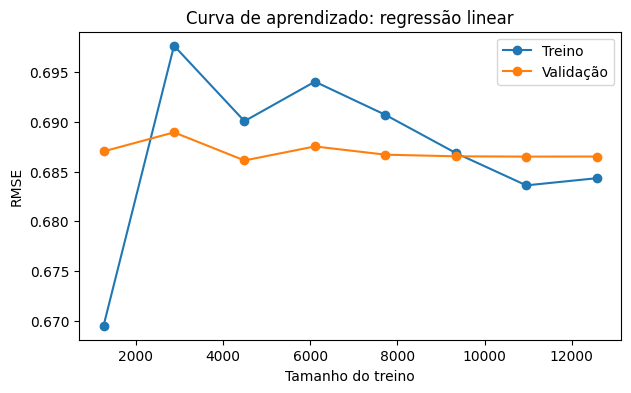

,n_treino,RMSE_treino_medio,RMSE_validacao_medio
0,1257,0.6695,0.6870
1,2874,0.6976,0.6889
2,4490,0.6901,0.6861
3,6107,0.6940,0.6875
4,7724,0.6907,0.6867
5,9340,0.6869,0.6865
6,10957,0.6836,0.6865
7,12574,0.6843,0.6865


In [61]:
# ============================================================
# 9. Learning curve
# ============================================================

train_sizes, train_scores, valid_scores = learning_curve(
    linear_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_rmse = -train_scores
valid_rmse = -valid_scores

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_rmse.mean(axis=1), marker="o", label="Treino")
plt.plot(train_sizes, valid_rmse.mean(axis=1), marker="o", label="Validação")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.title("Curva de aprendizado: regressão linear")
plt.legend()
plt.show()

pd.DataFrame({
    "n_treino": train_sizes,
    "RMSE_treino_medio": train_rmse.mean(axis=1),
    "RMSE_validacao_medio": valid_rmse.mean(axis=1)
})

## 10. Regularização: Ridge, Lasso e Elastic Net

A regularização altera a função objetivo. Em vez de apenas minimizar erro quadrático, penalizamos coeficientes grandes.

Ridge usa penalização L2. Ela encolhe coeficientes, mas raramente zera variáveis.

Lasso usa penalização L1. Ela pode zerar coeficientes e funcionar como seleção de variáveis.

Elastic Net mistura L1 e L2.

Aqui a padronização é parte do modelo. Sem escala comum, a penalização fica injusta: variáveis medidas em unidades grandes ou pequenas recebem tratamentos incompatíveis.

In [62]:
# ============================================================
# 10.1 Ridge com GridSearchCV
# ============================================================

ridge_pipe = make_pipeline(
    StandardScaler(),
    Ridge(random_state=RANDOM_STATE)
)

ridge_grid = {
    "ridge__alpha": np.logspace(-3, 3, 13)
}

ridge_search = GridSearchCV(
    ridge_pipe,
    ridge_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

ridge_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", ridge_search.best_params_)
print("Melhor RMSE CV:", -ridge_search.best_score_)

cv_results.append(cv_regression_summary(ridge_search.best_estimator_, X_train, y_train, "Ridge tunado"))
pd.DataFrame(cv_results)

Melhores hiperparâmetros: {'ridge__alpha': np.float64(31.622776601683793)}
Melhor RMSE CV: 0.6864160289635709


,modelo,CV_RMSE_medio,CV_RMSE_dp,CV_MAE_medio,CV_R2_medio,Train_RMSE_medio
0,LinearRegression,0.6865,0.0124,0.5127,0.4978,0.6843
1,Ridge tunado,0.6864,0.0123,0.5133,0.4979,0.6844


In [63]:
# ============================================================
# 10.2 Lasso com GridSearchCV
# ============================================================

lasso_pipe = make_pipeline(
    StandardScaler(),
    Lasso(max_iter=20_000, random_state=RANDOM_STATE)
)

lasso_grid = {
    "lasso__alpha": np.logspace(-4, 1, 12)
}

lasso_search = GridSearchCV(
    lasso_pipe,
    lasso_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

lasso_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", lasso_search.best_params_)
print("Melhor RMSE CV:", -lasso_search.best_score_)

cv_results.append(cv_regression_summary(lasso_search.best_estimator_, X_train, y_train, "Lasso tunado"))
pd.DataFrame(cv_results)

Melhores hiperparâmetros: {'lasso__alpha': np.float64(0.002310129700083158)}
Melhor RMSE CV: 0.6863994400088977


,modelo,CV_RMSE_medio,CV_RMSE_dp,CV_MAE_medio,CV_R2_medio,Train_RMSE_medio
0,LinearRegression,0.6865,0.0124,0.5127,0.4978,0.6843
1,Ridge tunado,0.6864,0.0123,0.5133,0.4979,0.6844
2,Lasso tunado,0.6864,0.0124,0.5137,0.4980,0.6845


In [41]:
# ============================================================
# 10.3 Elastic Net com busca aleatória
# ============================================================

elastic_pipe = make_pipeline(
    StandardScaler(),
    ElasticNet(max_iter=20_000, random_state=RANDOM_STATE)
)

elastic_distributions = {
    "elasticnet__alpha": np.logspace(-4, 1, 100),
    "elasticnet__l1_ratio": np.linspace(0.05, 0.95, 19)
}

elastic_search = RandomizedSearchCV(
    elastic_pipe,
    elastic_distributions,
    n_iter=40,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

elastic_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", elastic_search.best_params_)
print("Melhor RMSE CV:", -elastic_search.best_score_)

cv_results.append(cv_regression_summary(elastic_search.best_estimator_, X_train, y_train, "Elastic Net tunado"))
pd.DataFrame(cv_results)

Melhores hiperparâmetros: {'elasticnet__l1_ratio': np.float64(0.7), 'elasticnet__alpha': np.float64(0.002310129700083158)}
Melhor RMSE CV: 0.6882756865969437


,modelo,CV_RMSE_medio,CV_RMSE_dp,CV_MAE_medio,CV_R2_medio,Train_RMSE_medio
0,LinearRegression,0.6884,0.0128,0.5134,0.4950,0.6861
1,Ridge tunado,0.6883,0.0127,0.5141,0.4952,0.6862
2,Lasso tunado,0.6883,0.0127,0.5144,0.4952,0.6863
3,Elastic Net tunado,0.6883,0.0127,0.5143,0.4952,0.6862


In [26]:
# ============================================================
# 10.4 Coeficientes regularizados
# ============================================================

coef_regularized = pd.DataFrame({
    "Linear": linear_pipeline.fit(X_train, y_train).named_steps["linearregression"].coef_,
    "Ridge": ridge_search.best_estimator_.named_steps["ridge"].coef_,
    "Lasso": lasso_search.best_estimator_.named_steps["lasso"].coef_,
    "ElasticNet": elastic_search.best_estimator_.named_steps["elasticnet"].coef_,
}, index=feature_cols)

coef_regularized["Lasso_zerou"] = np.isclose(coef_regularized["Lasso"], 0)

coef_regularized.sort_values("Linear", key=np.abs, ascending=False)

,Linear,Ridge,Lasso,ElasticNet,Lasso_zerou
Latitude,-0.8088,-0.7864,-0.7881,-0.7934,False
Longitude,-0.7855,-0.7630,-0.7627,-0.7689,False
MedInc,0.6734,0.6730,0.6609,0.6664,False
AveBedrms,0.2747,0.2694,0.2423,0.2557,False
AveRooms,-0.2464,-0.2428,-0.2144,-0.2279,False
HouseAge,0.0995,0.1019,0.0994,0.0998,False
AveOccup,-0.0370,-0.0372,-0.0343,-0.0355,False
Population,0.0058,0.0067,0.0039,0.0049,False


## 11. Gradiente descendente: quando escala deixa de ser detalhe

A regressão linear pode ser ajustada por solução fechada ou por métodos iterativos. O `SGDRegressor` usa descida do gradiente estocástica.

Aqui a escala das variáveis afeta a geometria do problema. Sem padronização, o algoritmo pode convergir lentamente, oscilar ou favorecer direções dominadas por variáveis de grande escala.

In [27]:
# ============================================================
# 11. SGDRegressor com e sem padronização
# ============================================================

sgd_raw = SGDRegressor(
    loss="squared_error",
    penalty=None,
    max_iter=5_000,
    tol=1e-4,
    random_state=RANDOM_STATE
)

sgd_scaled = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        loss="squared_error",
        penalty=None,
        max_iter=5_000,
        tol=1e-4,
        random_state=RANDOM_STATE
    )
)

sgd_raw.fit(X_train, y_train)
sgd_scaled.fit(X_train, y_train)

pred_sgd_raw = sgd_raw.predict(X_test)
pred_sgd_scaled = sgd_scaled.predict(X_test)

pd.DataFrame([
    regression_metrics(y_test, pred_sgd_raw, "SGD sem escala"),
    regression_metrics(y_test, pred_sgd_scaled, "SGD com escala")
])

,modelo,RMSE,MAE,R2
0,SGD sem escala,6.3741e+13,5.8335e+13,-4.2378e+27
1,SGD com escala,6.4473e-01,4.8282e-01,5.6643e-01


Se o resultado do SGD sem escala ficar ruim ou instável, isso não significa que “regressão linear é ruim”. Significa que o método de otimização sofreu com a escala. O mesmo modelo conceitual pode ter comportamentos computacionais diferentes dependendo do algoritmo de ajuste.

## 12. Regressão linear com atributos não lineares

Um modelo linear nos parâmetros pode representar relações não lineares nas variáveis se criarmos atributos transformados.

Exemplo: ao incluir \(x^2\), \(x_1x_2\) e outras interações, o modelo continua linear nos coeficientes, mas a fronteira funcional fica mais flexível.

Esse passo aproxima a abordagem de Géron: começar com linear, diagnosticar viés e testar engenharia de atributos. A regularização Ridge entra para conter explosão de variância.

In [28]:
# ============================================================
# 12. PolynomialFeatures + Ridge
# ============================================================

poly_ridge_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(include_bias=False),
    StandardScaler(),
    Ridge(random_state=RANDOM_STATE)
)

poly_param_dist = {
    "polynomialfeatures__degree": [1, 2, 3],
    "ridge__alpha": np.logspace(-2, 3, 60)
}

poly_search = RandomizedSearchCV(
    poly_ridge_pipe,
    poly_param_dist,
    n_iter=25,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

poly_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", poly_search.best_params_)
print("Melhor RMSE CV:", -poly_search.best_score_)

cv_results.append(cv_regression_summary(poly_search.best_estimator_, X_train, y_train, "Polynomial Ridge tunado"))
pd.DataFrame(cv_results).sort_values("CV_RMSE_medio")

Melhores hiperparâmetros: {'ridge__alpha': np.float64(36.25117049988532), 'polynomialfeatures__degree': 1}
Melhor RMSE CV: 0.6337119812304721


,modelo,CV_RMSE_medio,CV_RMSE_dp,CV_MAE_medio,CV_R2_medio,Train_RMSE_medio
3,Elastic Net tunado,0.6336,0.0114,0.4720,0.5722,0.6311
2,Lasso tunado,0.6336,0.0114,0.4722,0.5722,0.6313
1,Ridge tunado,0.6337,0.0116,0.4718,0.5721,0.6311
4,Polynomial Ridge tunado,0.6337,0.0116,0.4718,0.5721,0.6312
0,LinearRegression,0.6337,0.0115,0.4717,0.5721,0.6310


## 13. Escolha final com base na validação cruzada

Até aqui, o conjunto de teste continuou intocado. Agora escolhemos os modelos candidatos usando apenas a validação cruzada no treino. Depois avaliamos no teste uma única vez.

Essa disciplina é o coração do pipeline preditivo.

In [29]:
# ============================================================
# 13. Avaliação final no teste
# ============================================================

candidate_models = {
    "Baseline: mediana": baseline,
    "LinearRegression": linear_pipeline,
    "Ridge tunado": ridge_search.best_estimator_,
    "Lasso tunado": lasso_search.best_estimator_,
    "Elastic Net tunado": elastic_search.best_estimator_,
    "Polynomial Ridge tunado": poly_search.best_estimator_,
    "SGD com escala": sgd_scaled
}

final_rows = []

for name, model in candidate_models.items():
    # Reajusta no treino inteiro quando necessário
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    final_rows.append(regression_metrics(y_test, pred, name))

final_results = pd.DataFrame(final_rows).sort_values("RMSE")
final_results

,modelo,RMSE,MAE,R2
1,LinearRegression,0.6429,0.4828,0.5689
2,Ridge tunado,0.6431,0.4829,0.5686
5,Polynomial Ridge tunado,0.6432,0.4829,0.5685
4,Elastic Net tunado,0.6433,0.4831,0.5683
3,Lasso tunado,0.6437,0.4835,0.5678
6,SGD com escala,0.6447,0.4828,0.5664
0,Baseline: mediana,0.9959,0.7694,-0.0344


## 14. Diagnóstico de resíduos do melhor modelo

Uma boa métrica média pode esconder padrões de erro. O diagnóstico de resíduos pergunta:

O modelo erra mais em casas caras?  
O erro muda com a previsão?  
Há assimetria?  
Há grupos nos quais o erro é sistematicamente maior?

Essas perguntas vêm da tradição estatística, mas são igualmente relevantes em machine learning aplicado.

Melhor modelo pelo RMSE no teste: LinearRegression


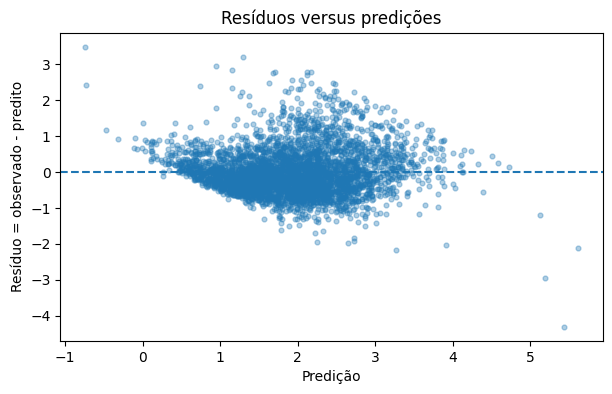

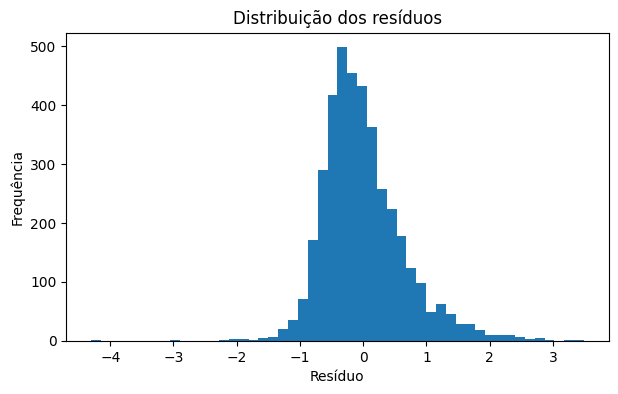

count    3.9300e+03
mean     1.2769e-05
std      6.4295e-01
min     -4.3076e+00
25%     -4.2101e-01
50%     -9.8590e-02
75%      3.2324e-01
max      3.4927e+00
Name: MedHouseVal, dtype: float64

In [30]:
# ============================================================
# 14. Resíduos
# ============================================================

best_model_name = final_results.iloc[0]["modelo"]
best_model = candidate_models[best_model_name]

best_model.fit(X_train, y_train)
pred_test = best_model.predict(X_test)
residuals = y_test - pred_test

print("Melhor modelo pelo RMSE no teste:", best_model_name)

plt.figure(figsize=(7, 4))
plt.scatter(pred_test, residuals, alpha=0.35, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predição")
plt.ylabel("Resíduo = observado - predito")
plt.title("Resíduos versus predições")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50)
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

pd.Series(residuals).describe()

In [31]:
# ============================================================
# 14.1 Erro por faixa de valor observado
# ============================================================

error_df = X_test.copy()
error_df["y_real"] = y_test
error_df["y_pred"] = pred_test
error_df["erro"] = error_df["y_real"] - error_df["y_pred"]
error_df["erro_abs"] = error_df["erro"].abs()
error_df["faixa_valor_real"] = pd.qcut(error_df["y_real"], q=5, duplicates="drop")

error_by_value = (
    error_df
    .groupby("faixa_valor_real", observed=True)
    .agg(
        n=("erro_abs", "size"),
        MAE=("erro_abs", "mean"),
        RMSE=("erro", lambda s: np.sqrt(np.mean(s**2))),
        valor_real_medio=("y_real", "mean"),
        predicao_media=("y_pred", "mean")
    )
)

error_by_value

,n,MAE,RMSE,valor_real_medio,predicao_media
faixa_valor_real,,,,,
"(0.149, 1.039]",786,0.4435,0.5471,0.7797,1.1239
"(1.039, 1.519]",787,0.4080,0.5216,1.2912,1.5745
"(1.519, 1.963]",785,0.3815,0.4734,1.7274,1.9341
"(1.963, 2.711]",786,0.3554,0.4480,2.3130,2.2498
"(2.711, 4.964]",786,0.8253,1.0344,3.4924,2.7213


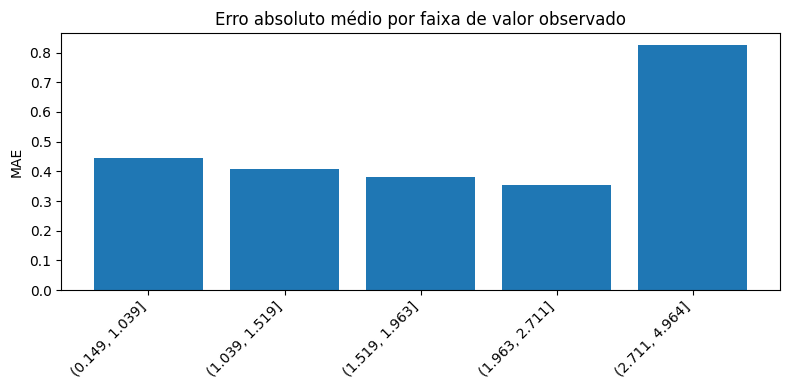

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(error_by_value.index.astype(str), error_by_value["MAE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE")
plt.title("Erro absoluto médio por faixa de valor observado")
plt.tight_layout()
plt.show()

Se o erro cresce muito nas faixas mais caras, isso é um indício de que o modelo linear tem dificuldade na cauda superior do alvo. Isso pode vir de censura no alvo, não linearidade, falta de variáveis relevantes ou heterogeneidade geográfica.

## 15. Importância por permutação

Coeficientes ajudam na regressão linear, mas podem ser difíceis de comparar quando há colinearidade, regularização e atributos transformados.

A importância por permutação faz outra pergunta: quanto a métrica piora quando embaralhamos uma variável no teste? Isso mede contribuição preditiva fora da amostra, não causalidade.

,variavel,piora_RMSE_media,piora_RMSE_dp
6,Latitude,6.6690e-01,8.5068e-03
7,Longitude,6.4406e-01,1.0491e-02
0,MedInc,5.0276e-01,1.0771e-02
3,AveBedrms,6.2346e-02,2.8693e-03
2,AveRooms,5.9538e-02,2.8589e-03
1,HouseAge,1.7072e-02,1.6140e-03
5,AveOccup,8.1187e-04,5.8405e-05
4,Population,2.9455e-05,7.8945e-05


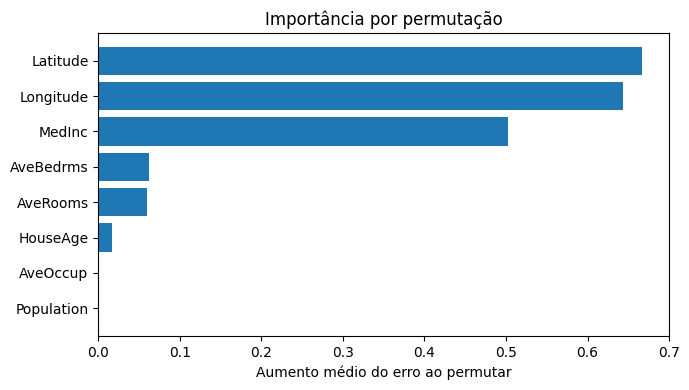

In [33]:
# ============================================================
# 15. Permutation importance no melhor modelo
# ============================================================

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "variavel": feature_cols,
    "piora_RMSE_media": perm.importances_mean,
    "piora_RMSE_dp": perm.importances_std
}).sort_values("piora_RMSE_media", ascending=False)

display(perm_df)

plt.figure(figsize=(7, 4))
plt.barh(perm_df["variavel"][::-1], perm_df["piora_RMSE_media"][::-1])
plt.xlabel("Aumento médio do erro ao permutar")
plt.title("Importância por permutação")
plt.tight_layout()
plt.show()

## 16. Mini-relatório final

Preencha depois de rodar o notebook.

**Problema.** Prever valor mediano de casas por região na Califórnia.

**Baseline.** O baseline pela mediana serve como piso de comparação.

**Modelo linear comum.** Melhorou bastante sobre o baseline, mas apresentou limitações de flexibilidade.

**Padronização.** Não alterou materialmente as previsões do OLS, mas tornou coeficientes comparáveis em escala padronizada e melhorou o condicionamento numérico. Foi indispensável para regularização e SGD.

**Colinearidade.** Variáveis correlacionadas dificultaram leitura isolada de coeficientes. Isso afetou mais interpretação do que predição.

**Regularização.** Ridge/Lasso/Elastic Net controlaram coeficientes. O ganho preditivo dependeu da validação cruzada, não de preferência teórica.

**Atributos polinomiais.** Aumentaram flexibilidade. A validação cruzada decidiu se a flexibilidade compensou o risco de sobreajuste.

**Erro.** A análise por faixa do alvo indicou se o modelo erra mais em regiões caras, baratas ou intermediárias.

**Conclusão técnica.** O melhor modelo deve ser escolhido pela métrica validada e pela estabilidade do erro, não pela sofisticação do algoritmo.

## 17. Exercícios para transformar este notebook em estudo ativo

1. Troque a métrica principal de RMSE para MAE. A escolha do melhor modelo muda?

2. Remova `Latitude` e `Longitude`. O desempenho piora? O modelo fica mais interpretável?

3. Use `RobustScaler` no lugar de `StandardScaler`. Há diferença relevante?

4. Compare `KFold` com `ShuffleSplit`. A variabilidade da métrica muda?

5. Faça uma versão com validação geográfica: regiões próximas não devem cair aleatoriamente em treino e validação. Esse é um passo mais realista para dados espaciais.

6. Substitua regressão por classificação: transforme o alvo em “acima ou abaixo do percentil 75” e refaça o pipeline com regressão logística, SVM, árvore e Random Forest.

7. Crie um relatório curto respondendo: “qual modelo eu colocaria em produção como baseline e por quê?”

## Referências de estudo

Este notebook foi desenhado como síntese didática, não como cópia de um material específico.

Para aprofundar:

- *An Introduction to Statistical Learning with Applications in Python*, especialmente regressão linear, problemas potenciais da regressão e regularização.
- *Machine Learning in Python with scikit-learn*, especialmente pipeline, validação cruzada, tuning e modelos lineares.
- *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, especialmente projeto ponta a ponta, treinamento de modelos lineares, gradiente descendente e regularização.

# Primeira modelagem

In [2]:
# ============================================================
# 0. Configuração inicial
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.inspection import permutation_importance

set_config(display="diagram")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)

In [3]:
# ============================================================
# 1. Carregar o dataset e filtrar outliers do target
# ============================================================

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = housing.target_names[0]  # "MedHouseVal"
feature_cols = housing.feature_names

# # Aplica o filtro removendo valores maiores ou iguais a 5
# df = df[df[target_col] < 4.9999]

print(housing.DESCR[:900])
print("\nShape após a remoção:", df.shape)
df.head()


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousa

Shape após a remoção: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422


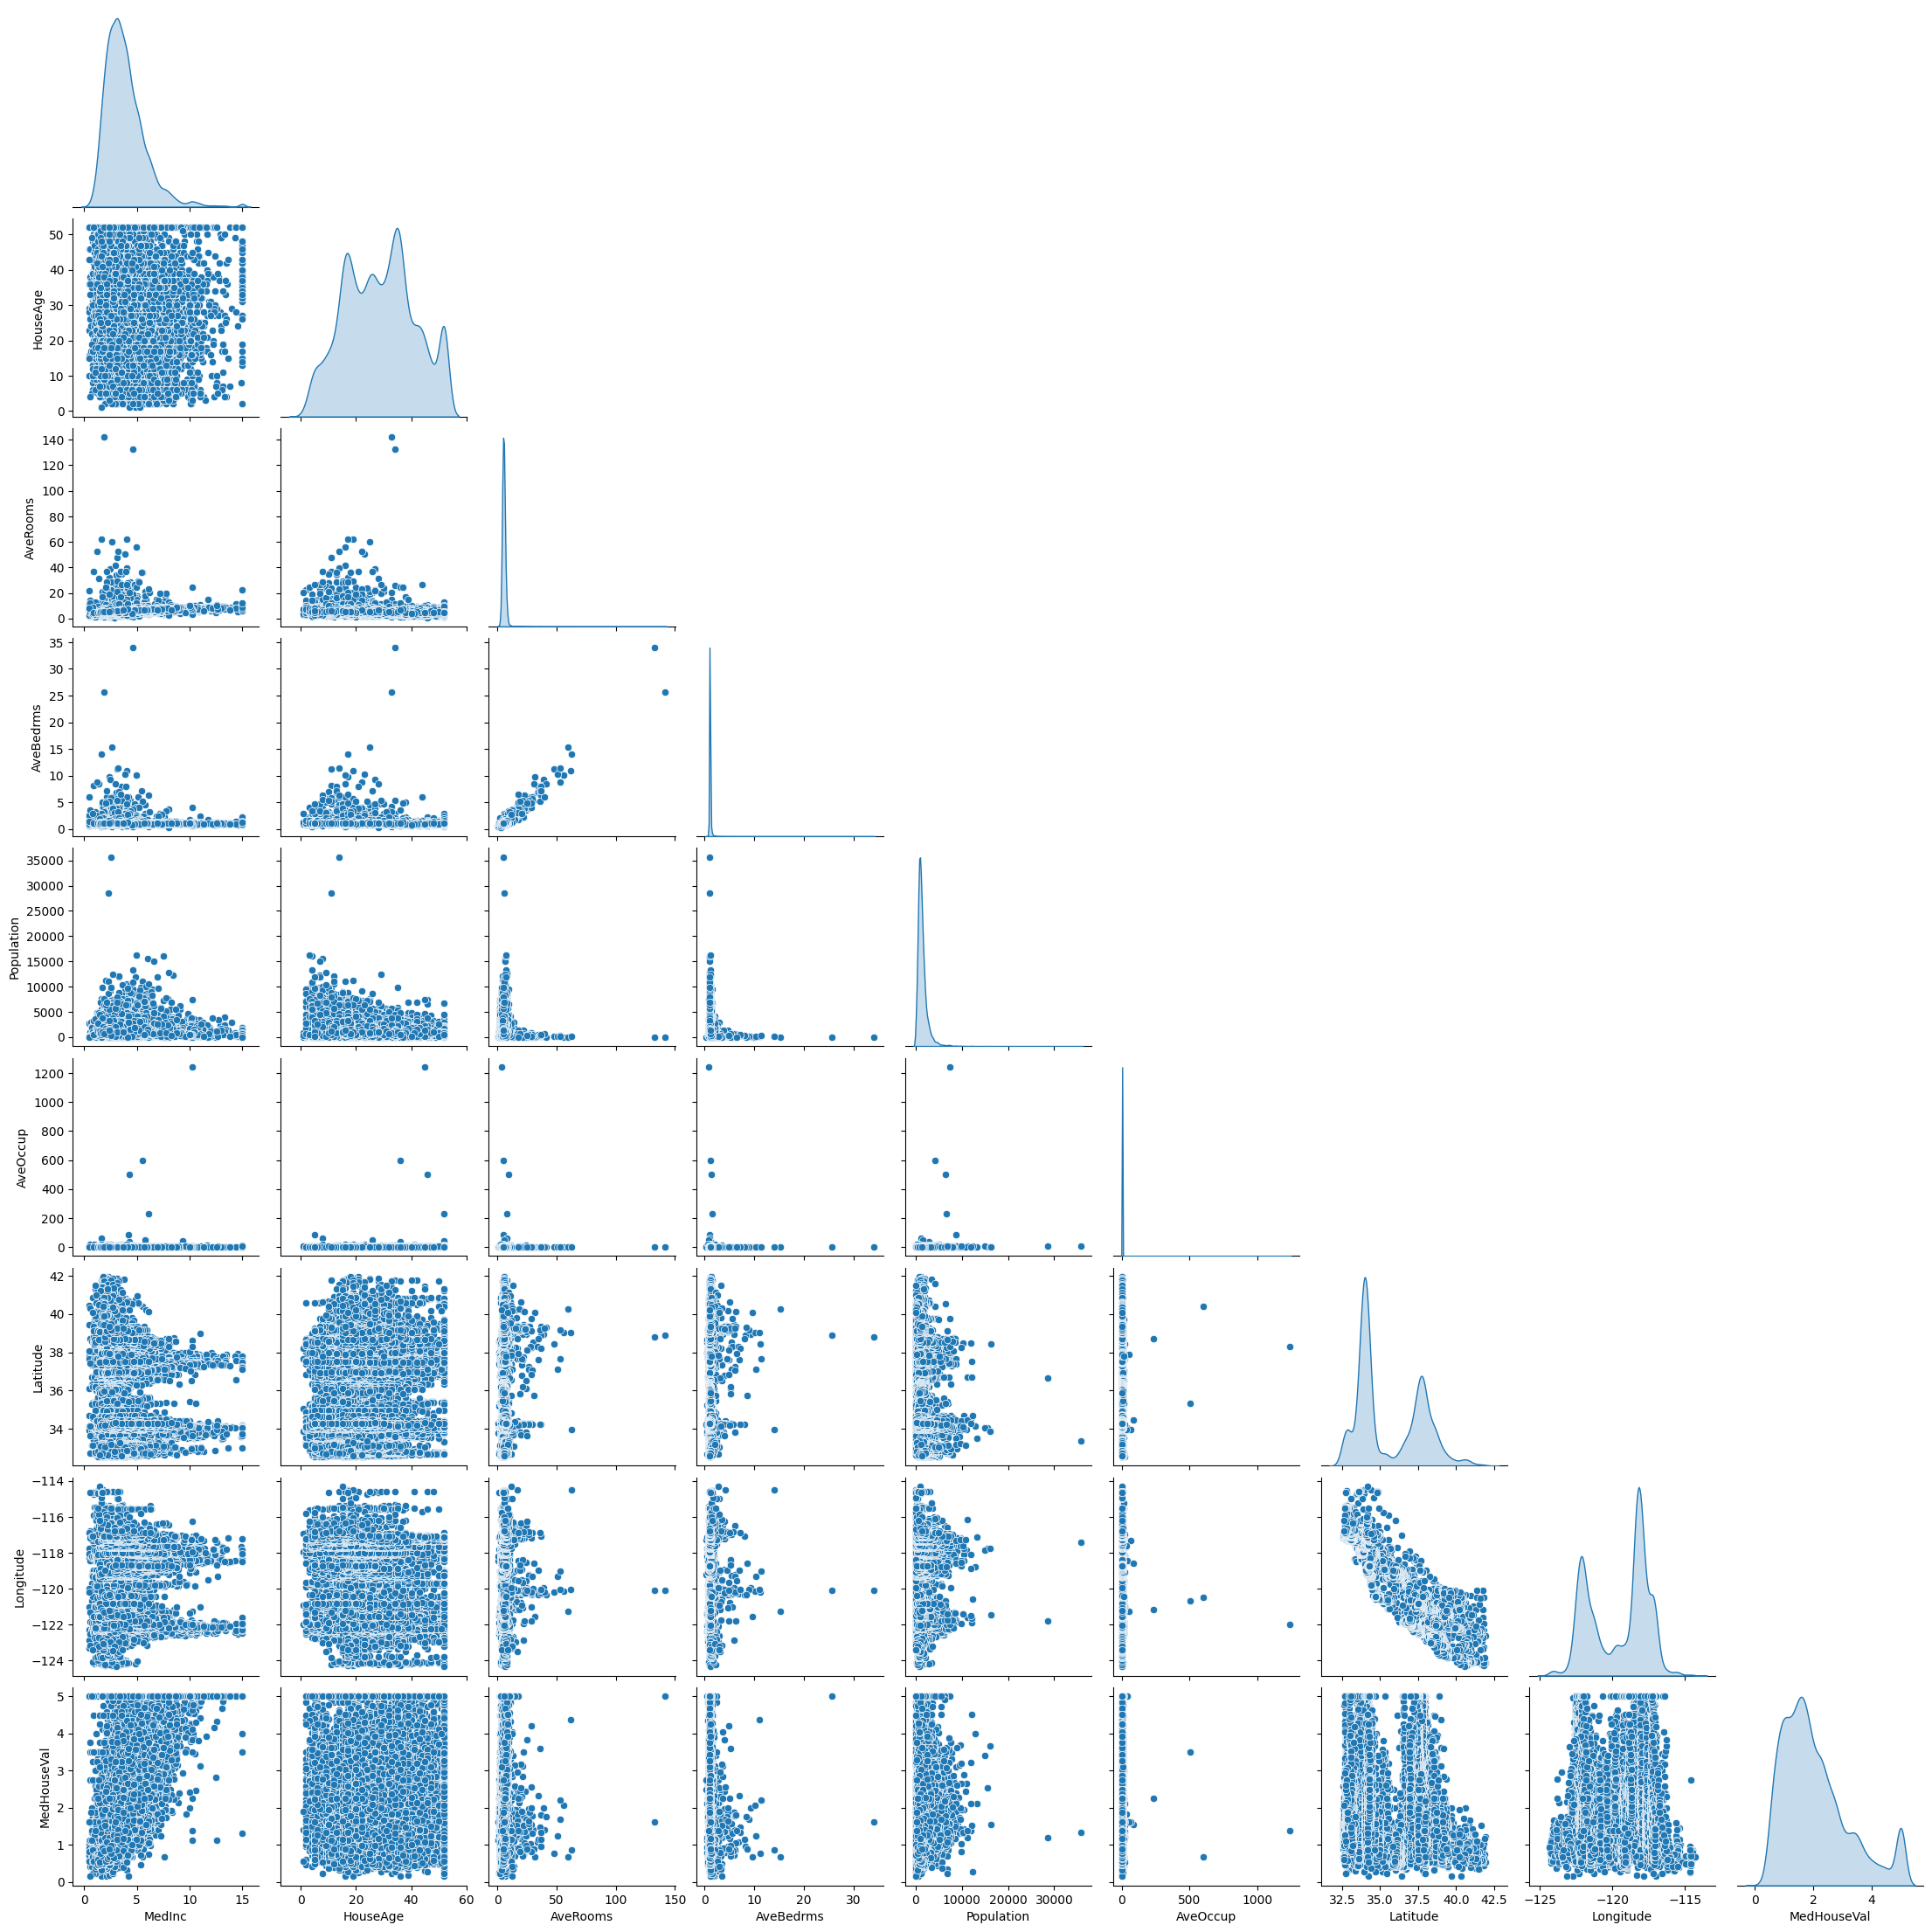

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df,
    vars=df.columns,
    # hue="grupo",          # opcional, equivalente a colorir por categori
    diag_kind="kde",      # ou "hist"
    corner=True           # mostra só metade da matriz
)

plt.show()

In [4]:
df[(df["AveRooms"] >= 5) & (df["AveBedrms"] >= 5)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1024,3.1500,16.0,29.8529,5.3235,202.0,1.9804,38.52,-120.00,1.406
1102,2.4028,17.0,31.7778,9.7037,47.0,1.7407,40.06,-121.54,0.675
1234,4.4063,13.0,28.7573,5.3010,252.0,2.4466,38.26,-120.33,1.558
1238,3.3542,10.0,28.1129,5.6048,298.0,2.4032,38.29,-120.27,1.038
1239,3.0750,13.0,33.9897,6.8247,267.0,2.7526,38.31,-120.27,1.083
1240,3.1250,11.0,47.5152,11.1818,82.0,2.4848,38.42,-120.19,0.775
1867,2.6250,8.0,23.8889,5.9444,36.0,2.0000,38.95,-119.95,1.875
1872,2.4917,27.0,38.8409,9.2727,97.0,2.2045,38.94,-119.93,2.000
1912,4.9750,16.0,56.2692,10.1538,54.0,2.0769,39.01,-120.16,2.063
1913,4.0714,19.0,61.8125,11.0000,112.0,2.3333,39.01,-120.06,4.375


In [5]:
df[df["Population"] < 100]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
59,2.5625,2.0,2.7719,0.7544,94.0,1.6491,37.82,-122.29,0.600
61,6.1183,49.0,5.8696,1.2609,86.0,3.7391,37.82,-122.29,0.750
73,0.4999,46.0,1.7143,0.5714,18.0,2.5714,37.81,-122.29,0.675
121,4.9643,37.0,7.1064,1.1489,98.0,2.0851,37.85,-122.24,3.350
700,6.5000,20.0,6.4516,0.8065,83.0,2.6774,37.69,-122.03,3.400
...,...,...,...,...,...,...,...,...,...
20248,8.0000,28.0,2.8889,0.3333,29.0,3.2222,34.25,-119.23,2.750
20349,7.3004,32.0,5.7241,0.7586,63.0,2.1724,34.17,-119.08,1.250
20353,5.0066,12.0,3.8000,1.4667,69.0,4.6000,34.13,-119.05,2.750
20502,2.9821,45.0,4.4815,0.9259,67.0,2.4815,34.33,-118.68,3.250


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Dataset de treino com alvo para EDA
train_df = X_train.copy()
train_df[target_col] = y_train

train_df.describe().T

sample = train_df.sample(n=min(5000, len(train_df)), random_state=RANDOM_STATE)



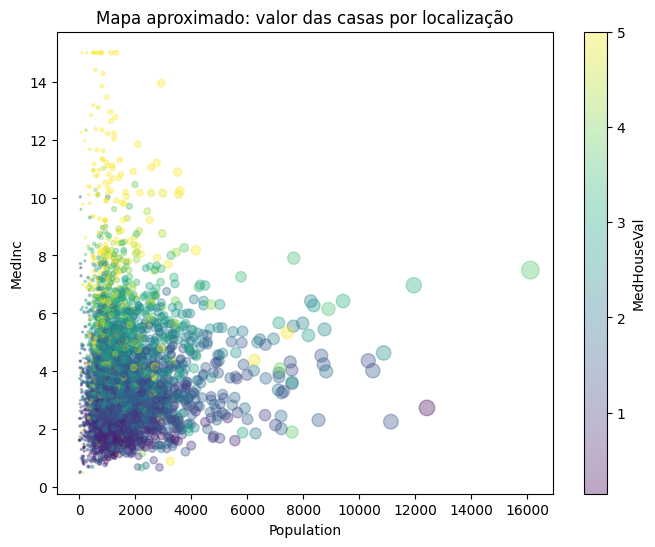

In [7]:
# Cria um novo DataFrame apenas com 5000 linhas aleatórias
sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    sample["Population"],
    sample["MedInc"],
    c=sample[target_col],
    s=np.maximum(sample["Population"] / 100, 2),
    alpha=0.35
)
plt.xlabel("Population")
plt.ylabel("MedInc")
plt.title("Mapa aproximado: valor das casas por localização")
plt.colorbar(scatter, label="MedHouseVal")
plt.show()

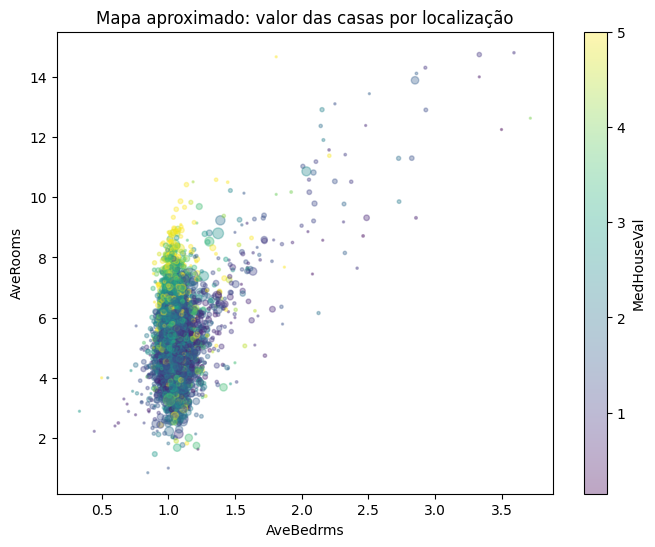

In [9]:
# Cria um novo DataFrame apenas com 5000 linhas aleatórias
sample = df[(df["AveRooms"] <= 15) & (df["AveBedrms"] <= 10)].sample(n=5000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    sample["AveBedrms"],
    sample["AveRooms"],
    c=sample[target_col],
    s=np.maximum(sample["Population"] / 100, 2),
    alpha=0.35
)
plt.xlabel("AveBedrms")
plt.ylabel("AveRooms")
plt.title("Mapa aproximado: valor das casas por localização")
plt.colorbar(scatter, label="MedHouseVal")
plt.show()

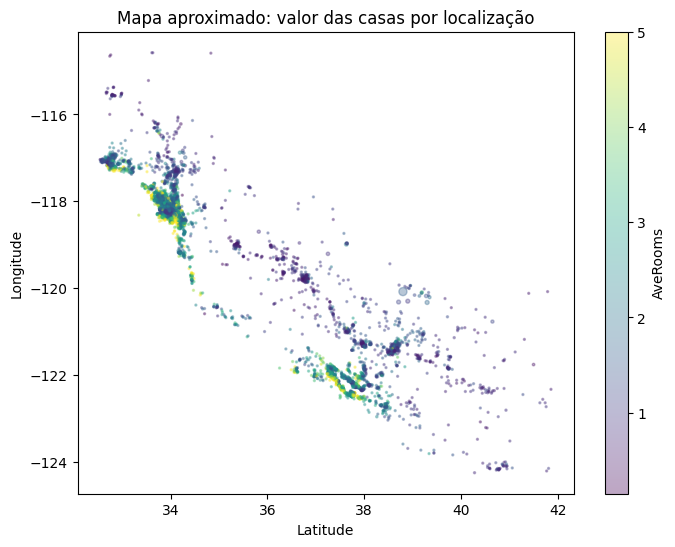

In [13]:
# Cria um novo DataFrame apenas com 5000 linhas aleatórias
sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    sample["Latitude"],
    sample["Longitude"],
    c=sample[target_col],
    s=np.maximum(sample["AveBedrms"], 2),
    alpha=0.35
)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Mapa aproximado: valor das casas por localização")
plt.colorbar(scatter, label="AveRooms")
plt.show()

In [14]:
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # raio médio da Terra em km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


centros = {
    "sf": (37.7749, -122.4194),
    "la": (34.0522, -118.2437),
    "sd": (32.7157, -117.1611),
    "sj": (37.3382, -121.8863),
    "sac": (38.5816, -121.4944)
}

for nome, (lat_c, lon_c) in centros.items():
    df[f"dist_{nome}_km"] = haversine_km(
        df["Latitude"],
        df["Longitude"],
        lat_c,
        lon_c
    )

colunas_dist = [f"dist_{nome}_km" for nome in centros.keys()]

df["dist_centro_mais_proximo_km"] = df[colunas_dist].min(axis=1)

In [15]:
df["log_dist_centro_mais_proximo"] = np.log1p(df["dist_centro_mais_proximo_km"])

In [16]:
df["prox_centro_urbano"] = 1 / (1 + df["dist_centro_mais_proximo_km"])

In [17]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,dist_sf_km,dist_la_km,dist_sd_km,dist_sj_km,dist_sac_km,dist_centro_mais_proximo_km,log_dist_centro_mais_proximo,prox_centro_urbano
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526,20.3295,556.5312,735.5043,67.4249,101.0662,20.3295,3.0601,0.0469
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585,19.9081,554.2819,733.2393,65.0444,102.2543,19.9081,3.0401,0.0478
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521,17.8354,554.6127,733.5281,64.8830,104.2149,17.8354,2.9357,0.0531
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413,17.0641,555.1963,734.0977,65.3108,104.7631,17.0641,2.8939,0.0554
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422,17.0641,555.1963,734.0977,65.3108,104.7631,17.0641,2.8939,0.0554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.0455,1.1333,845.0,2.5606,39.48,-121.09,0.781,221.9923,654.5332,830.6347,248.0549,105.8282,105.8282,4.6712,0.0094
20636,2.5568,18.0,6.1140,1.3158,356.0,3.1228,39.49,-121.21,0.771,217.7236,659.7501,836.2490,246.4153,103.9532,103.9532,4.6535,0.0095
20637,1.7000,17.0,5.2055,1.1201,1007.0,2.3256,39.43,-121.22,0.923,211.4968,654.0452,830.7027,239.7360,97.2716,97.2716,4.5877,0.0102
20638,1.8672,18.0,5.3295,1.1719,741.0,2.1232,39.43,-121.32,0.847,207.3533,657.7009,834.6756,237.7756,95.5337,95.5337,4.5699,0.0104


In [29]:
df_v2 = df[(df["AveRooms"] <= 15) & (df["AveBedrms"] <= 5)]

In [30]:
df_v2

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,dist_sf_km,dist_la_km,dist_sd_km,dist_sj_km,dist_sac_km,dist_centro_mais_proximo_km,log_dist_centro_mais_proximo,prox_centro_urbano
0,8.3252,41.0,6.9841,1.0238,322.0,2.5556,37.88,-122.23,4.526,20.3295,556.5312,735.5043,67.4249,101.0662,20.3295,3.0601,0.0469
1,8.3014,21.0,6.2381,0.9719,2401.0,2.1098,37.86,-122.22,3.585,19.9081,554.2819,733.2393,65.0444,102.2543,19.9081,3.0401,0.0478
2,7.2574,52.0,8.2881,1.0734,496.0,2.8023,37.85,-122.24,3.521,17.8354,554.6127,733.5281,64.8830,104.2149,17.8354,2.9357,0.0531
3,5.6431,52.0,5.8174,1.0731,558.0,2.5479,37.85,-122.25,3.413,17.0641,555.1963,734.0977,65.3108,104.7631,17.0641,2.8939,0.0554
4,3.8462,52.0,6.2819,1.0811,565.0,2.1815,37.85,-122.25,3.422,17.0641,555.1963,734.0977,65.3108,104.7631,17.0641,2.8939,0.0554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.0455,1.1333,845.0,2.5606,39.48,-121.09,0.781,221.9923,654.5332,830.6347,248.0549,105.8282,105.8282,4.6712,0.0094
20636,2.5568,18.0,6.1140,1.3158,356.0,3.1228,39.49,-121.21,0.771,217.7236,659.7501,836.2490,246.4153,103.9532,103.9532,4.6535,0.0095
20637,1.7000,17.0,5.2055,1.1201,1007.0,2.3256,39.43,-121.22,0.923,211.4968,654.0452,830.7027,239.7360,97.2716,97.2716,4.5877,0.0102
20638,1.8672,18.0,5.3295,1.1719,741.0,2.1232,39.43,-121.32,0.847,207.3533,657.7009,834.6756,237.7756,95.5337,95.5337,4.5699,0.0104


In [31]:
df_v2 = df_v2.drop(['Latitude', 'Longitude', 'dist_centro_mais_proximo_km'], axis=1)


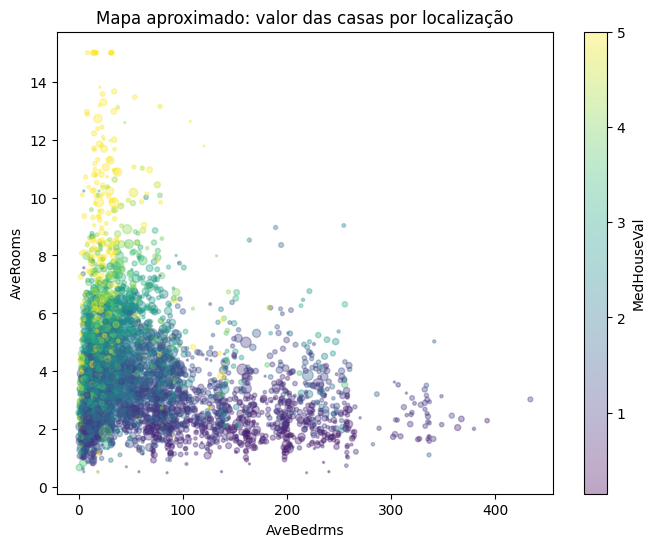

In [24]:
# Cria um novo DataFrame apenas com 5000 linhas aleatórias
sample = df_v2.sample(n=5000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    sample["dist_centro_mais_proximo_km"],
    sample["MedInc"],
    c=sample[target_col],
    s=np.maximum(sample["Population"] / 100, 2),
    alpha=0.35
)
plt.xlabel("AveBedrms")
plt.ylabel("AveRooms")
plt.title("Mapa aproximado: valor das casas por localização")
plt.colorbar(scatter, label="MedHouseVal")
plt.show()

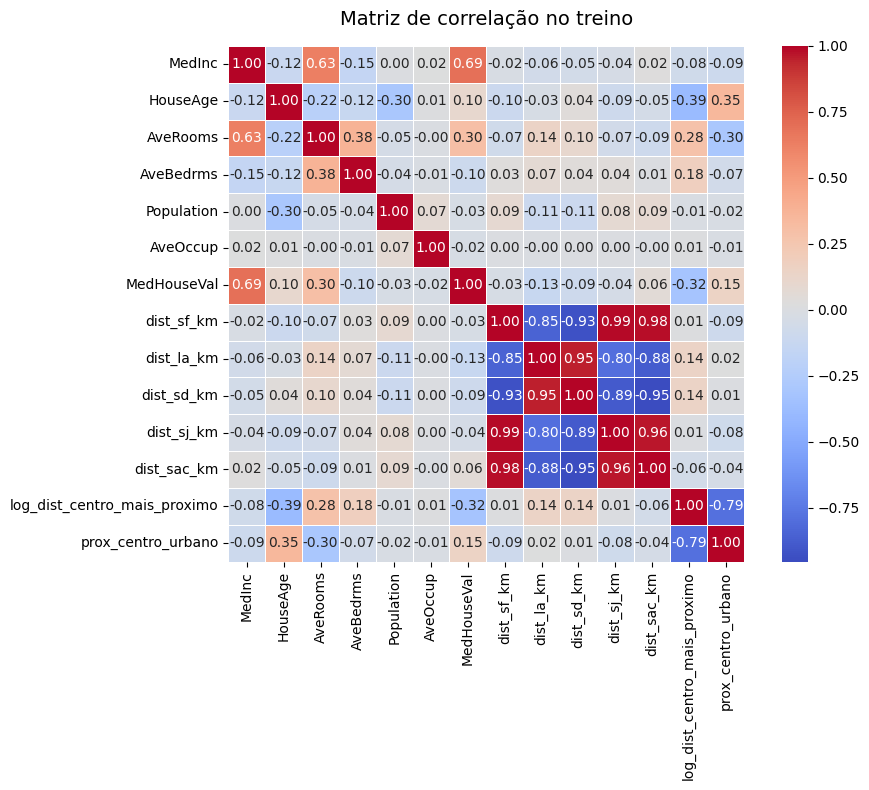

log_dist_centro_mais_proximo   -0.3240
dist_la_km                     -0.1299
AveBedrms                      -0.0957
dist_sd_km                     -0.0917
dist_sj_km                     -0.0413
dist_sf_km                     -0.0305
Population                     -0.0264
AveOccup                       -0.0239
dist_sac_km                     0.0596
HouseAge                        0.1049
prox_centro_urbano              0.1490
AveRooms                        0.3020
MedInc                          0.6891
MedHouseVal                     1.0000
Name: MedHouseVal, dtype: float64

In [33]:
# ============================================================
# 3.3 Correlações lineares
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calcula a matriz de correlação
corr = df_v2.corr(numeric_only=True)

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Plota o heatmap com Seaborn
sns.heatmap(
    corr,
    annot=True,  # Mostra os valores numéricos dentro dos quadrados
    fmt=".2f",  # Define 2 casas decimais para os números
    cmap="coolwarm",  # Paleta de cores (azul para negativo, vermelho para positivo)
    square=True,  # Mantém os quadrados perfeitamente proporcionais
    linewidths=0.5,  # Linha fina separando cada quadrado
)

# Define o título e ajusta o layout
plt.title("Matriz de correlação no treino", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Mantém a sua ordenação do target
corr[target_col].sort_values(ascending=True)


In [55]:
target_col = 'MedHouseVal'

# Captura todas as colunas, removendo a target
feature_cols = df_v2.columns.drop(target_col)
feature_cols

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'dist_sf_km', 'dist_la_km', 'dist_sd_km', 'dist_sj_km', 'dist_sac_km',
       'log_dist_centro_mais_proximo', 'prox_centro_urbano'],
      dtype='str')

In [56]:
# ============================================================
# 2. Separação treino/teste
# ============================================================

X = df_v2[feature_cols].copy()
y = df_v2[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Média do alvo no treino:", y_train.mean().round(3))
print("Média do alvo no teste:", y_test.mean().round(3))

Treino: (16424, 13) Teste: (4107, 13)
Média do alvo no treino: 2.075
Média do alvo no teste: 2.053


In [57]:
# ============================================================
# 4. Baseline com DummyRegressor
# ============================================================

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def regression_metrics(y_true, y_pred, label="modelo"):
    return {
        "modelo": label,
        # Nova função oficial para o RMSE no scikit-learn moderno:
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# O restante do seu código roda sem alterações
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)
results_holdout = [regression_metrics(y_test, pred_base, "Baseline: mediana")]

pd.DataFrame(results_holdout)

,modelo,RMSE,MAE,R2
0,Baseline: mediana,1.1867,0.8909,-0.0458


In [58]:
# ============================================================
# 5. Regressão linear sem padronização
# ============================================================

lin_raw = LinearRegression()
lin_raw.fit(X_train, y_train)

pred_lin_raw = lin_raw.predict(X_test)
results_holdout.append(regression_metrics(y_test, pred_lin_raw, "LinearRegression sem escala"))

coef_raw = pd.Series(lin_raw.coef_, index=feature_cols, name="coeficiente_sem_escala")
df_coef = (coef_raw.sort_values(key=np.abs, ascending=False).to_frame())
display(df_coef.style.format("{:.5f}"))

pd.DataFrame(results_holdout)

,coeficiente_sem_escala
AveBedrms,0.83621
MedInc,0.43602
prox_centro_urbano,-0.37409
log_dist_centro_mais_proximo,-0.21417
AveRooms,-0.09141
dist_sf_km,-0.00636
dist_sac_km,0.00549
AveOccup,-0.00311
HouseAge,0.00255
dist_sj_km,0.00170


,modelo,RMSE,MAE,R2
0,Baseline: mediana,1.1867,0.8909,-0.0458
1,LinearRegression sem escala,0.7057,0.5128,0.6302


In [59]:
# ============================================================
# 6.1 LinearRegression com StandardScaler no pipeline
# ============================================================

lin_scaled = make_pipeline(
    RobustScaler(),
    LinearRegression()
)

lin_scaled.fit(X_train, y_train)
pred_lin_scaled = lin_scaled.predict(X_test)

comparison = pd.DataFrame([
    regression_metrics(y_test, pred_lin_raw, "OLS sem escala"),
    regression_metrics(y_test, pred_lin_scaled, "OLS com RobustScaler")
])

comparison["diferença_RMSE_vs_sem_escala"] = comparison["RMSE"] - comparison.loc[0, "RMSE"]
comparison

,modelo,RMSE,MAE,R2,diferença_RMSE_vs_sem_escala
0,OLS sem escala,0.7057,0.5128,0.6302,0.0000e+00
1,OLS com RobustScaler,0.7057,0.5128,0.6302,1.5543e-15
